#KNN

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, auc

In [ ]:
dataset = pd.read_csv('/content/WSN-DS.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values
feature_names = dataset.columns[1:-1].tolist()  # Convert column names to a list
feature_names = np.array(feature_names)
print(X)
print(y)
print(feature_names)

[[5.0000000e+01 1.0000000e+00 1.0100000e+05 ... 1.3008535e+02
  0.0000000e+00 2.4694000e+00]
 [5.0000000e+01 0.0000000e+00 1.0104400e+05 ... 0.0000000e+00
  4.0000000e+00 6.9570000e-02]
 [5.0000000e+01 0.0000000e+00 1.0101000e+05 ... 0.0000000e+00
  3.0000000e+00 6.8980000e-02]
 ...
 [1.0030000e+03 0.0000000e+00 2.0109500e+05 ... 1.3926438e+02
  1.0000000e+00 9.4370000e-02]
 [1.0030000e+03 0.0000000e+00 2.0105100e+05 ... 1.5827492e+02
  3.0000000e+00 1.6047000e-01]
 [1.0250000e+03 0.0000000e+00 2.0210000e+05 ... 1.1500407e+02
  0.0000000e+00 1.0132500e+00]]
['Normal' 'Normal' 'Normal' ... 'Normal' 'Normal' 'Normal']
[' Time' ' Is_CH' ' who CH' ' Dist_To_CH' ' ADV_S' ' ADV_R' ' JOIN_S'
 ' JOIN_R' ' SCH_S' ' SCH_R' 'Rank' ' DATA_S' ' DATA_R' ' Data_Sent_To_BS'
 ' dist_CH_To_BS' ' send_code ' 'Expaned Energy']


In [ ]:
from sklearn.impute import SimpleImputer

# Impute all features (excluding target)
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X = imputer.fit_transform(X)  # Make sure X is full features

# Impute target if necessary (use most frequent)
imputer_y = SimpleImputer(strategy='most_frequent')
y = imputer_y.fit_transform(y.reshape(-1, 1)).ravel()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

             Feature    Importance
2             who CH  9.334234e+09
0               Time  2.930428e+07
12            DATA_R  8.208942e+06
8              SCH_S  3.753596e+06
14     dist_CH_To_BS  3.007901e+06
4              ADV_S  2.906604e+06
7             JOIN_R  1.765908e+06
11            DATA_S  1.334521e+06
13   Data_Sent_To_BS  1.203449e+06
3         Dist_To_CH  6.694454e+05
5              ADV_R  5.118687e+05
10              Rank  2.834152e+05
1              Is_CH  2.001554e+05
15        send_code   7.418390e+04
6             JOIN_S  2.310360e+04
9              SCH_R  2.069134e+04
16    Expaned Energy  9.648307e+03


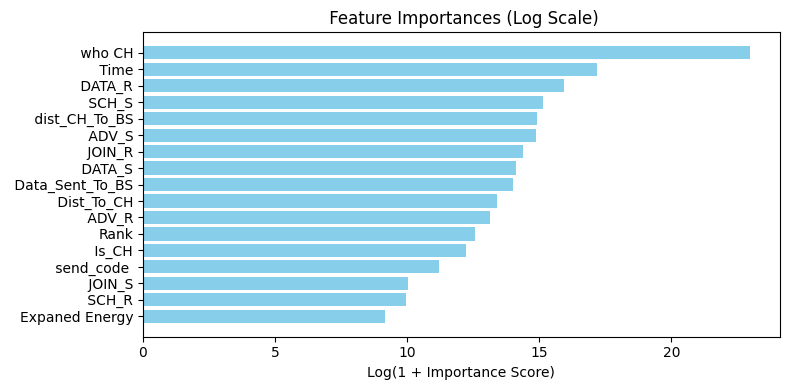

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

chi2_selector = SelectKBest(chi2, k=8)  # Set k to the desired number of features
X_train_selected = chi2_selector.fit_transform(X_train, y_train)
X_test_selected = chi2_selector.transform(X_test)

# Step 4: Display Chi-Square scores for each feature
chi_scores = chi2_selector.scores_  # Chi-Square scores for each feature
# Assign chi_scores to importances
importances = chi_scores
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print top features
print(importance_df)

# Plot feature importances
plt.figure(figsize=(8, 4))
plt.barh(importance_df['Feature'], np.log1p(importance_df['Importance']), color='skyblue')
plt.xlabel('Log(1 + Importance Score)')
plt.title(' Feature Importances (Log Scale)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_selected = sc.fit_transform(X_train_selected)
X_test_selected = sc.transform(X_test_selected)
print(X_train_selected)
print(X_test_selected)

[[-0.12248876 -0.39916057 -0.12978858 ... -0.49010544 -0.32089745
  -0.44860575]
 [ 0.2666377  -0.17335249 -0.12978858 ... -0.27878092 -0.32089745
  -0.44860575]
 [-0.78956268 -0.4299008  -0.12978858 ... -0.30226142 -0.32089745
  -0.44860575]
 ...
 [-0.06689926 -0.18869952 -0.12978858 ...  0.73088072 -0.32089745
  -0.44860575]
 [-0.17807825 -0.40161066 -0.12978858 ...  0.73088072 -0.32089745
  -0.44860575]
 [ 2.21226998  0.58609189 -0.12978858 ...  2.32755493 -0.32089745
  -0.44860575]]
[[-0.95633116 -0.43768207 -0.12978858 ...  2.02230839 -0.32089745
  -0.44860575]
 [-0.95633116 -0.43757688 -0.12978858 ... -0.74839098 -0.32089745
  -0.44860575]
 [-1.12309964 -0.44540946 -0.12978858 ...  0.40215367 -0.32089745
  -0.44860575]
 ...
 [ 0.76694315 -0.15022933 -0.12978858 ...  2.70324298 -0.32089745
  -0.44860575]
 [-1.06751015 -0.44288754 -0.12978858 ... -0.63098846 -0.32089745
  -0.44860575]
 [ 1.26724859  0.58870104  0.35538568 ... -1.05363752  0.72671414
   1.19543214]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
k_classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
k_classifier.fit(X_train_selected, y_train)
y_pred = k_classifier.predict(X_test_selected)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_selected, y_train)
k_classifier.fit(X_resampled, y_resampled)
y_pred = k_classifier.predict(X_test_selected)

from sklearn.metrics import accuracy_score
acc_score_knn= accuracy_score(y_test, y_pred)
print("Accuracy:", acc_score_knn)

from sklearn.metrics import classification_report
report_knn= classification_report(y_test, y_pred, output_dict=True)
report_df_KNN = pd.DataFrame(report_knn).transpose()

Accuracy: 0.980555963327239


In [ ]:
report_df_KNN

,precision,recall,f1-score,support
Blackhole,0.990089,0.994030,0.992056,2010.000000
Flooding,0.901774,0.998489,0.947670,662.000000
Grayhole,0.732286,0.941761,0.823917,2919.000000
Normal,0.996779,0.982798,0.989739,68014.000000
TDMA,0.894737,0.921687,0.908012,1328.000000
accuracy,0.980556,0.980556,0.980556,0.980556
macro avg,0.903133,0.967753,0.932279,74933.000000
weighted avg,0.983648,0.980556,0.981521,74933.000000


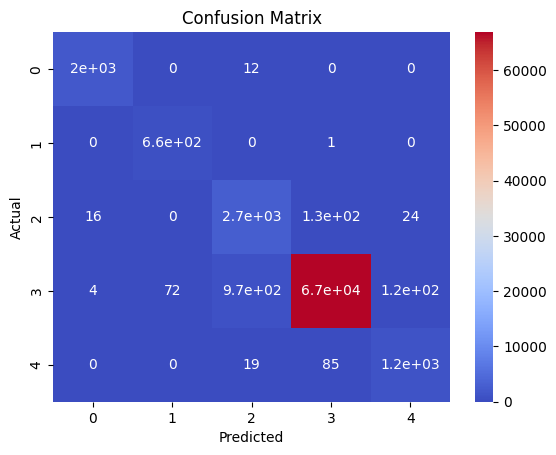

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm_knn = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_knn, annot=True, cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

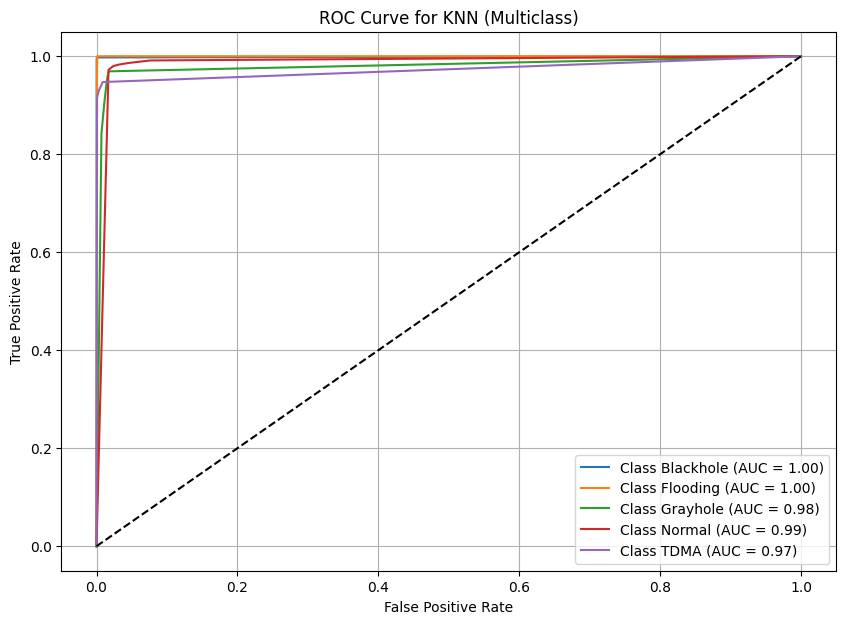

In [ ]:
!pip install scikit-learn
from sklearn.preprocessing import label_binarize


# Predict probabilities for all classes
y_score_knn = k_classifier.predict_proba(X_test_selected)

# Binarize y_test
classes = np.unique(y_test)
y_test_binarized = label_binarize(y_test, classes=classes)

# Plot ROC curve for each class
plt.figure(figsize=(10, 7))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score_knn[:, i])
    roc_auc = roc_auc_score(y_test_binarized[:, i], y_score_knn[:, i])
    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for KNN (Multiclass)')
plt.legend()
plt.grid()
plt.show()

#DECISION TREES

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_selected, y_train)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_selected, y_train)
dt_classifier.fit(X_resampled, y_resampled)
y_pred = dt_classifier.predict(X_test_selected)

from sklearn.metrics import accuracy_score
acc_score_dt= accuracy_score(y_test, y_pred)
print("Accuracy:", acc_score_dt)

from sklearn.metrics import classification_report
report_dt= classification_report(y_test, y_pred, output_dict=True)
report_df_DT = pd.DataFrame(report_knn).transpose()

Accuracy: 0.9836787530193639


In [ ]:
report_df_DT

,precision,recall,f1-score,support
Blackhole,0.990089,0.994030,0.992056,2010.000000
Flooding,0.901774,0.998489,0.947670,662.000000
Grayhole,0.732286,0.941761,0.823917,2919.000000
Normal,0.996779,0.982798,0.989739,68014.000000
TDMA,0.894737,0.921687,0.908012,1328.000000
accuracy,0.980556,0.980556,0.980556,0.980556
macro avg,0.903133,0.967753,0.932279,74933.000000
weighted avg,0.983648,0.980556,0.981521,74933.000000


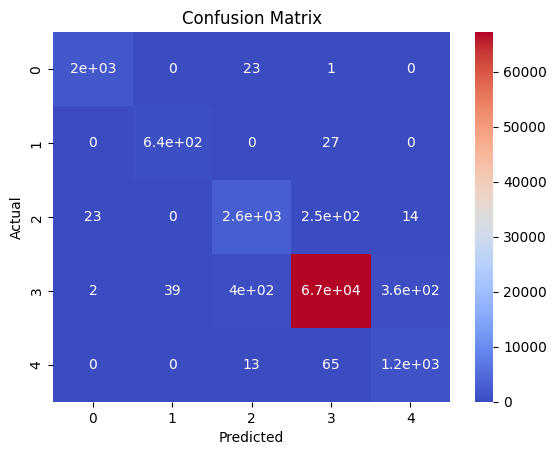

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm_dt = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_dt, annot=True, cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

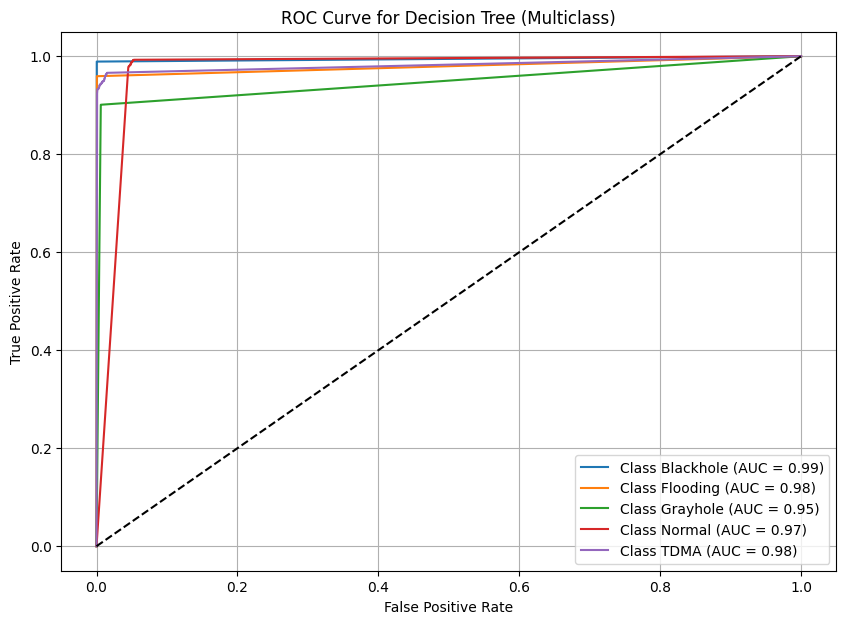

In [ ]:
y_score_knn = dt_classifier.predict_proba(X_test_selected)

# Binarize y_test
classes = np.unique(y_test)
y_test_binarized = label_binarize(y_test, classes=classes)

# Plot ROC curve for each class
plt.figure(figsize=(10, 7))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score_knn[:, i])
    roc_auc = roc_auc_score(y_test_binarized[:, i], y_score_knn[:, i])
    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Decision Tree (Multiclass)')
plt.legend()
plt.grid()
plt.show()

#RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=80, random_state=42)
rf_classifier.fit(X_train_selected, y_train)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_selected, y_train)
rf_classifier.fit(X_resampled, y_resampled)
y_pred = rf_classifier.predict(X_test_selected)

from sklearn.metrics import accuracy_score
acc_score_rf= accuracy_score(y_test, y_pred)
print("Accuracy:", acc_score_rf)

from sklearn.metrics import classification_report
report_rf= classification_report(y_test, y_pred, output_dict= True)
report_df_RF = pd.DataFrame(report_rf).transpose()
report_df_RF

Accuracy: 0.9837187887846476


,precision,recall,f1-score,support
Blackhole,0.988125,0.993532,0.990821,2010.000000
Flooding,0.918881,0.992447,0.954248,662.000000
Grayhole,0.842400,0.928400,0.883312,2919.000000
Normal,0.996362,0.986547,0.991430,68014.000000
TDMA,0.764059,0.941265,0.843455,1328.000000
accuracy,0.983719,0.983719,0.983719,0.983719
macro avg,0.901965,0.968438,0.932653,74933.000000
weighted avg,0.985342,0.983719,0.984251,74933.000000


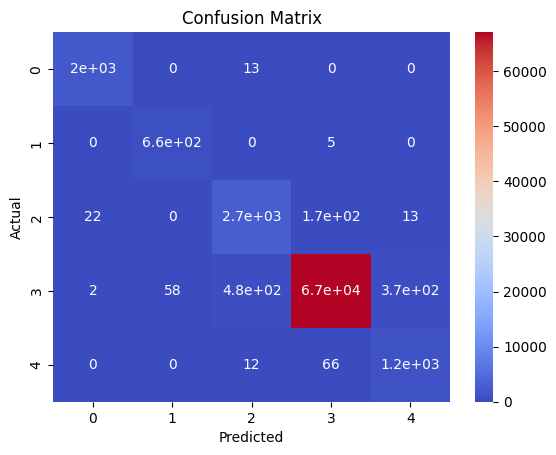

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm_rf = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_rf, annot=True, cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

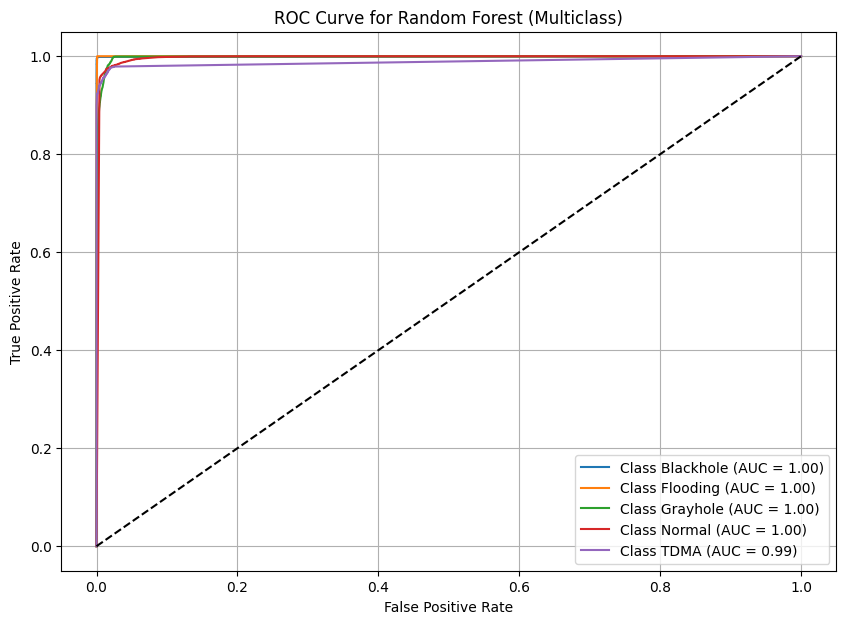

In [ ]:
y_score_knn = rf_classifier.predict_proba(X_test_selected)

# Binarize y_test
classes = np.unique(y_test)
y_test_binarized = label_binarize(y_test, classes=classes)

# Plot ROC curve for each class
plt.figure(figsize=(10, 7))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score_knn[:, i])
    roc_auc = roc_auc_score(y_test_binarized[:, i], y_score_knn[:, i])
    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest (Multiclass)')
plt.legend()
plt.grid()
plt.show()

#RESULT PLOTTING

<ipython-input-78-04a60cdeee86>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Algorithm', y='Accuracy', data=data, palette='pastel')


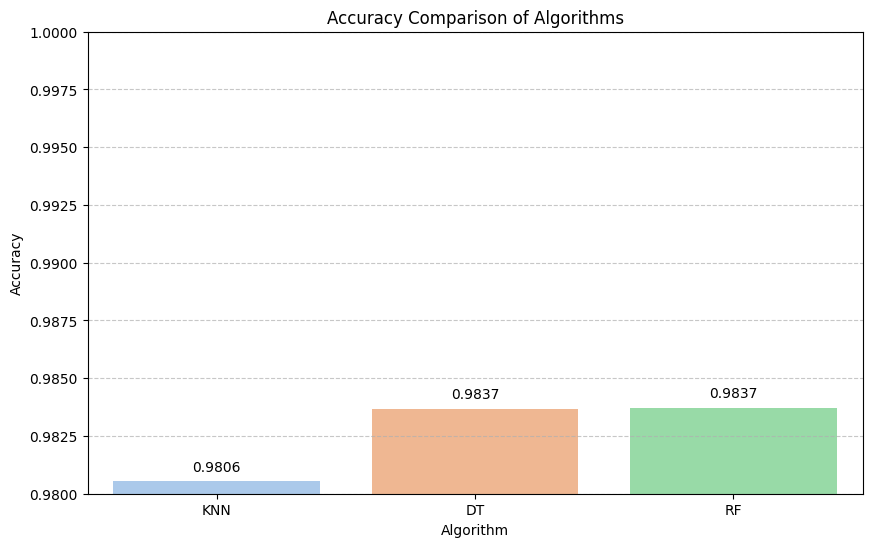

In [ ]:
# Data
data = pd.DataFrame({
    'Algorithm': ['KNN', 'DT', 'RF'],
    'Accuracy': [acc_score_knn, acc_score_dt, acc_score_rf]
})

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Algorithm', y='Accuracy', data=data, palette='pastel')
plt.ylim(0.98, 1)
plt.title('Accuracy Comparison of Algorithms')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, color='black',
                xytext=(0, 5),  # Slight vertical offset
                textcoords='offset points')

plt.show()

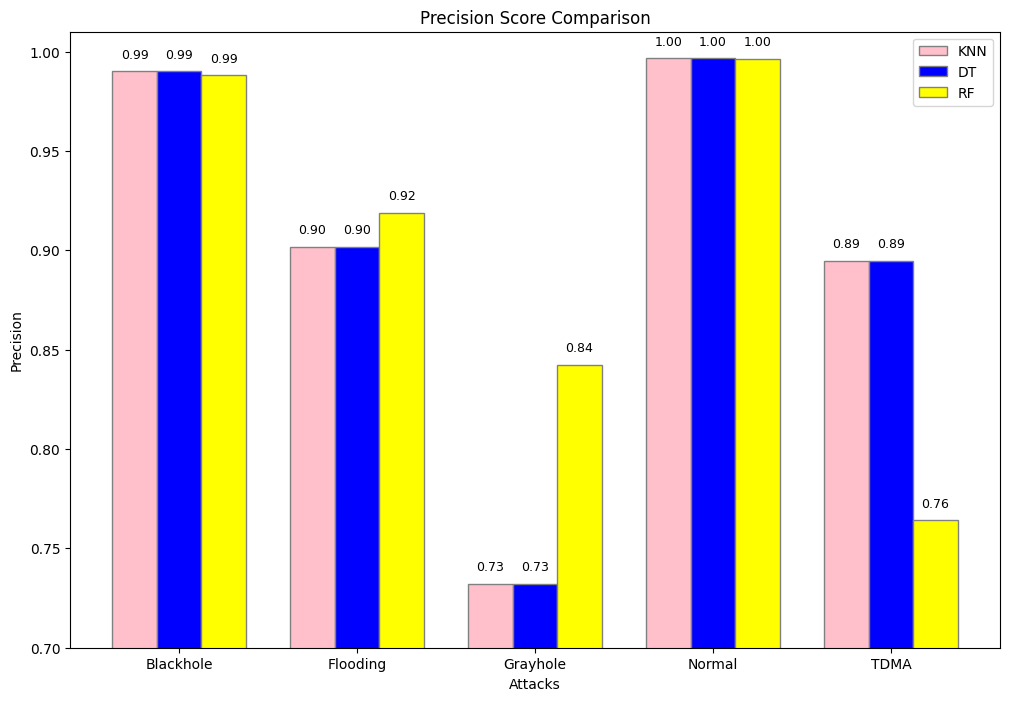

In [ ]:
barWidth = 0.25
fig, ax = plt.subplots(figsize =(12, 8))

precision_KNN = report_df_KNN['precision'].iloc[0:5].to_numpy()
precision_DT = report_df_DT['precision'].iloc[0:5].to_numpy()
precision_RF = report_df_RF['precision'].iloc[0:5].to_numpy()

br1 = np.arange(len(precision_KNN))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]

plt.ylim(0.70, 1.01)

bars1 = plt.bar(br1, precision_KNN, color ='pink', width = barWidth, edgecolor ='grey', label ='KNN')
bars2 = plt.bar(br2, precision_DT, color ='b', width = barWidth, edgecolor ='grey', label ='DT')
bars3 = plt.bar(br3, precision_RF, color ='yellow', width = barWidth, edgecolor ='grey', label ='RF')

plt.title('Precision Score Comparison')
plt.xlabel('Attacks')
plt.ylabel('Precision')
plt.xticks([r + barWidth for r in range(len(precision_KNN))],
        ['Blackhole', 'Flooding', 'Grayhole', 'Normal', 'TDMA'])

plt.legend()

# Add value labels above bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)

plt.show()


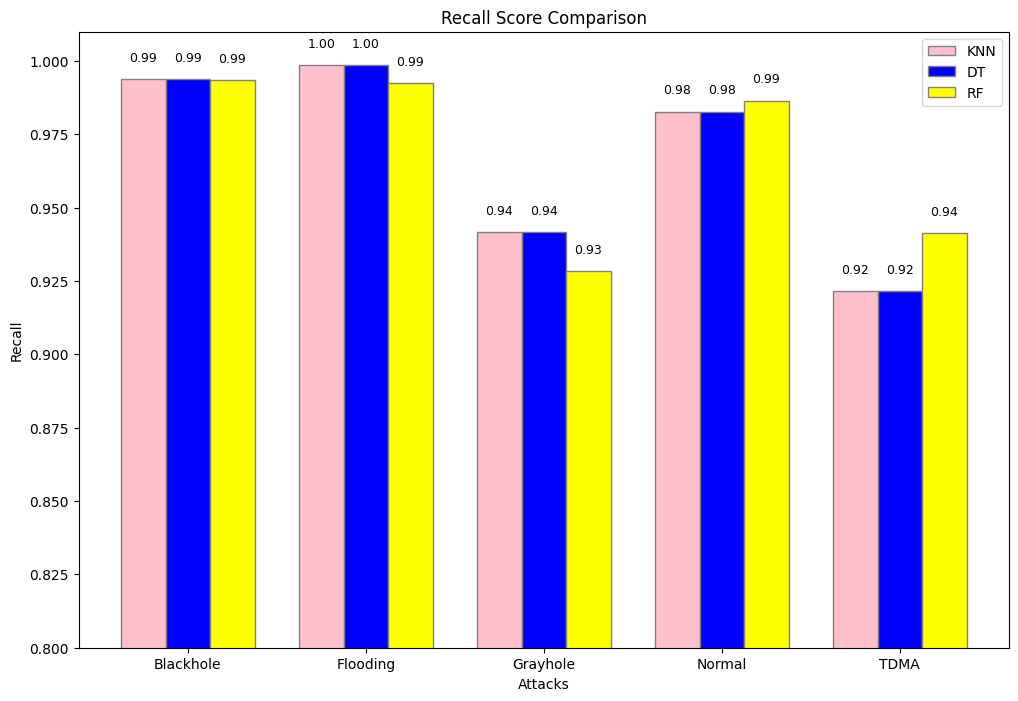

In [ ]:

barWidth = 0.25
fig, ax = plt.subplots(figsize =(12, 8))

recall_KNN = report_df_KNN['recall'].iloc[0:5].to_numpy()
recall_DT = report_df_DT['recall'].iloc[0:5].to_numpy()
recall_RF = report_df_RF['recall'].iloc[0:5].to_numpy()

br1 = np.arange(len(recall_KNN))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]

plt.ylim(0.8, 1.01)

bars1 = plt.bar(br1, recall_KNN, color ='pink', width = barWidth, edgecolor ='grey', label ='KNN')
bars2 = plt.bar(br2, recall_DT, color ='b', width = barWidth, edgecolor ='grey', label ='DT')
bars3 = plt.bar(br3, recall_RF, color ='yellow', width = barWidth, edgecolor ='grey', label ='RF')

plt.title('Recall Score Comparison')
plt.xlabel('Attacks')
plt.ylabel('Recall')
plt.xticks([r + barWidth for r in range(len(recall_KNN))],
        ['Blackhole', 'Flooding', 'Grayhole', 'Normal', 'TDMA'])

plt.legend()

# Annotate values above bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)

plt.show()


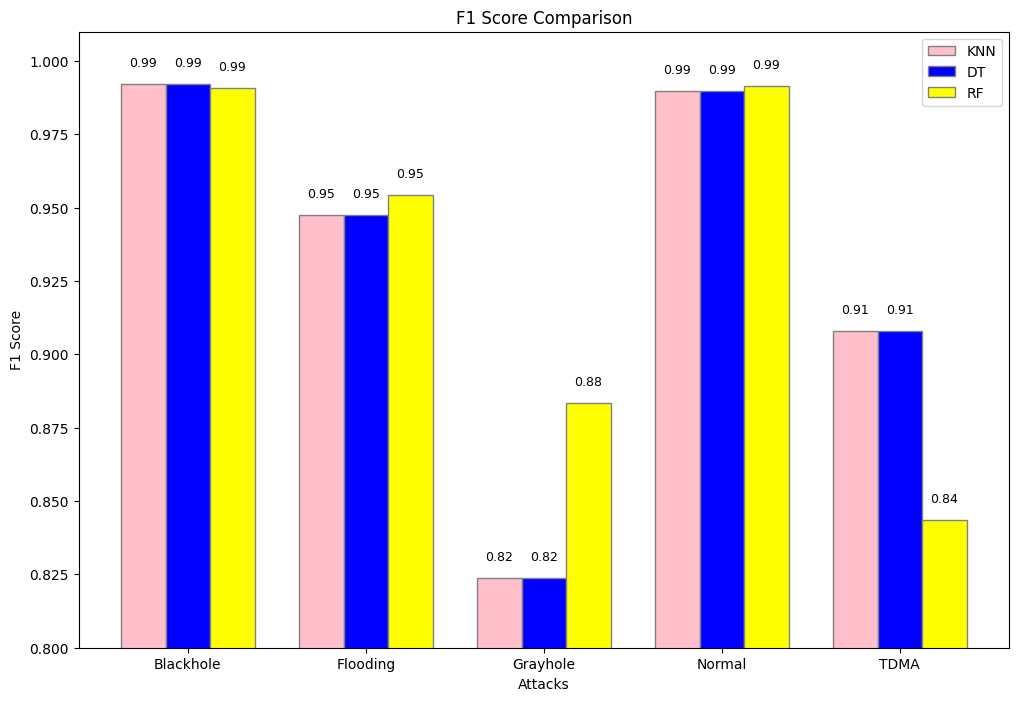

In [ ]:


barWidth = 0.25
fig, ax = plt.subplots(figsize =(12, 8))

f1_KNN = report_df_KNN['f1-score'].iloc[0:5].to_numpy()
f1_DT = report_df_DT['f1-score'].iloc[0:5].to_numpy()
f1_RF = report_df_RF['f1-score'].iloc[0:5].to_numpy()

br1 = np.arange(len(f1_KNN))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]

plt.ylim(0.8, 1.01)

# Now capture the bar plots correctly
bars1 = plt.bar(br1, f1_KNN, color ='pink', width = barWidth, edgecolor ='grey', label ='KNN')
bars2 = plt.bar(br2, f1_DT, color ='b', width = barWidth, edgecolor ='grey', label ='DT')
bars3 = plt.bar(br3, f1_RF, color ='yellow', width = barWidth, edgecolor ='grey', label ='RF')

plt.title('F1 Score Comparison')
plt.xlabel('Attacks')
plt.ylabel('F1 Score')
plt.xticks([r + barWidth for r in range(len(f1_KNN))],
        ['Blackhole', 'Flooding', 'Grayhole', 'Normal', 'TDMA'])

plt.legend()

# Now annotate the correct bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{yval:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.show()


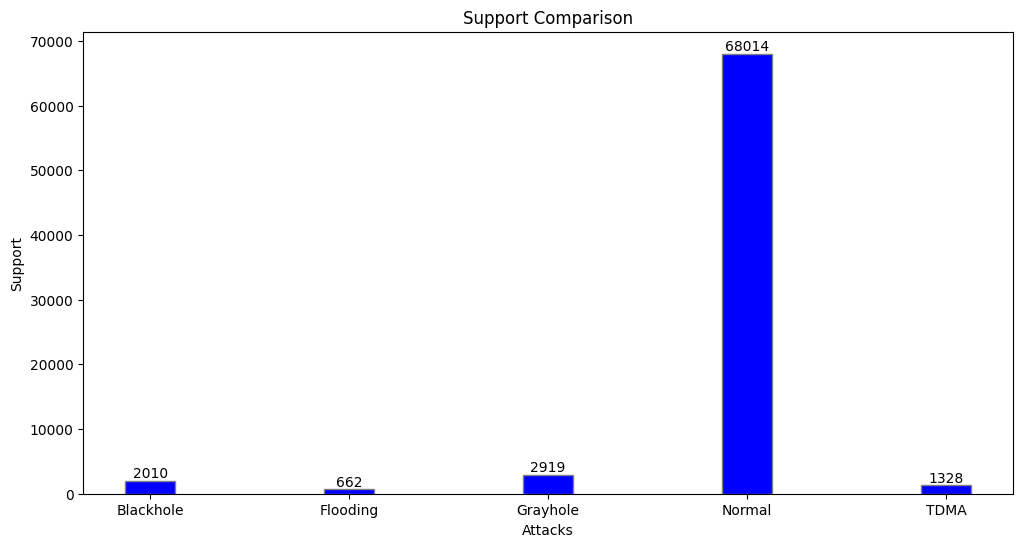

In [ ]:

barWidth = 0.25
fig, ax = plt.subplots(figsize =(12, 6))

support_DT = report_df_DT['support'].iloc[0:5].to_numpy()

br1 = np.arange(len(support_DT))  # Use support_DT's length directly
br2 = [x + barWidth for x in br1]

bars = plt.bar(br2, support_DT, color='b', width=barWidth, edgecolor='grey')

plt.title('Support Comparison')
plt.xlabel('Attacks')
plt.ylabel('Support')
plt.xticks([r + barWidth for r in range(len(support_DT))], ['Blackhole', 'Flooding', 'Grayhole', 'Normal', 'TDMA'])

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, int(yval), ha='center', va='bottom', fontsize=10)

plt.show()
